In [2]:
import pandas as pd

df = pd.read_csv("titanic_cleaned.csv")

print(df.shape)
print(df.head())

(889, 14)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male  embark_town alive  alone  
0    man        True  Southampton    no  False  
1  woman       False    Cherbourg   yes  False  
2  woman       False  Southampton   yes   True  
3  woman       False  Southampton   yes  False  
4    man        True  Southampton    no   True  


In [3]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

X shape: (889, 7)
y shape: (889,)

Features:
   pclass     sex   age  sibsp  parch     fare embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target:
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (711, 7)
X_test : (178, 7)
y_train: (711,)
y_test : (178,)


In [5]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [7]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [9]:
from sklearn.linear_model import LogisticRegression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [10]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [11]:
y_pred = logistic_pipeline.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Probability of class 1 (survived)
y_probs = logistic_pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_probs)

print("Logistic Regression Metrics")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)

print("\nConfusion Matrix:")
print(cm)

Logistic Regression Metrics
---------------------------
Accuracy : 0.8089887640449438
Precision: 0.7833333333333333
Recall   : 0.6911764705882353
F1 Score : 0.734375
ROC-AUC  : 0.8609625668449199

Confusion Matrix:
[[97 13]
 [21 47]]


In [13]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [14]:
decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [15]:
y_pred_dt = decision_tree_pipeline.predict(X_test)

print(y_pred_dt[:20])

[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Probability of class 1 (survived)
y_probs_dt = decision_tree_pipeline.predict_proba(X_test)[:, 1]

auc_dt = roc_auc_score(y_test, y_probs_dt)

print("Decision Tree Metrics")
print("---------------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)
print("ROC-AUC  :", auc_dt)

print("\nConfusion Matrix:")
print(cm_dt)

Decision Tree Metrics
---------------------
Accuracy : 0.7696629213483146
Precision: 0.6901408450704225
Recall   : 0.7205882352941176
F1 Score : 0.7050359712230215
ROC-AUC  : 0.754144385026738

Confusion Matrix:
[[88 22]
 [19 49]]


In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [18]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [19]:
y_pred_rf = random_forest_pipeline.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Probability of class 1 (survived)
y_probs_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_probs_rf)

print("Random Forest Metrics")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", auc_rf)

print("\nConfusion Matrix:")
print(cm_rf)

Random Forest Metrics
---------------------
Accuracy : 0.8202247191011236
Precision: 0.78125
Recall   : 0.7352941176470589
F1 Score : 0.7575757575757576
ROC-AUC  : 0.8179144385026736

Confusion Matrix:
[[96 14]
 [18 50]]


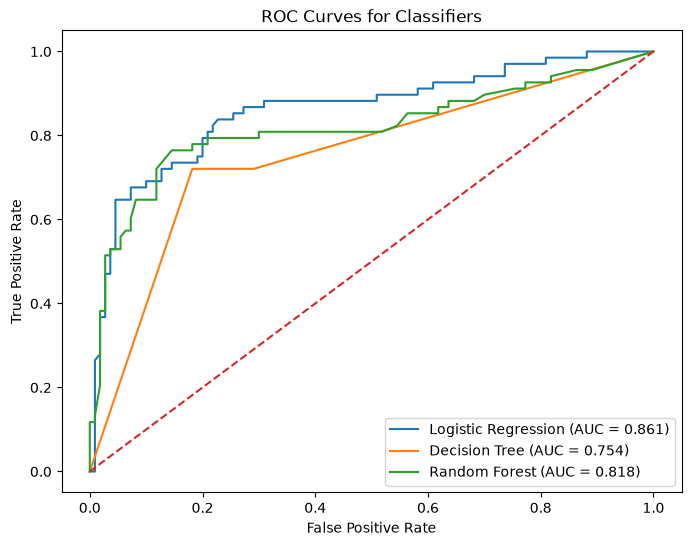

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)

    auc_score = roc_auc_score(y_test, y_probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classifiers")
plt.legend()
plt.show()

In [22]:
dt_model = decision_tree_pipeline.named_steps["classifier"]

In [23]:
feature_names = decision_tree_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(feature_names)

['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


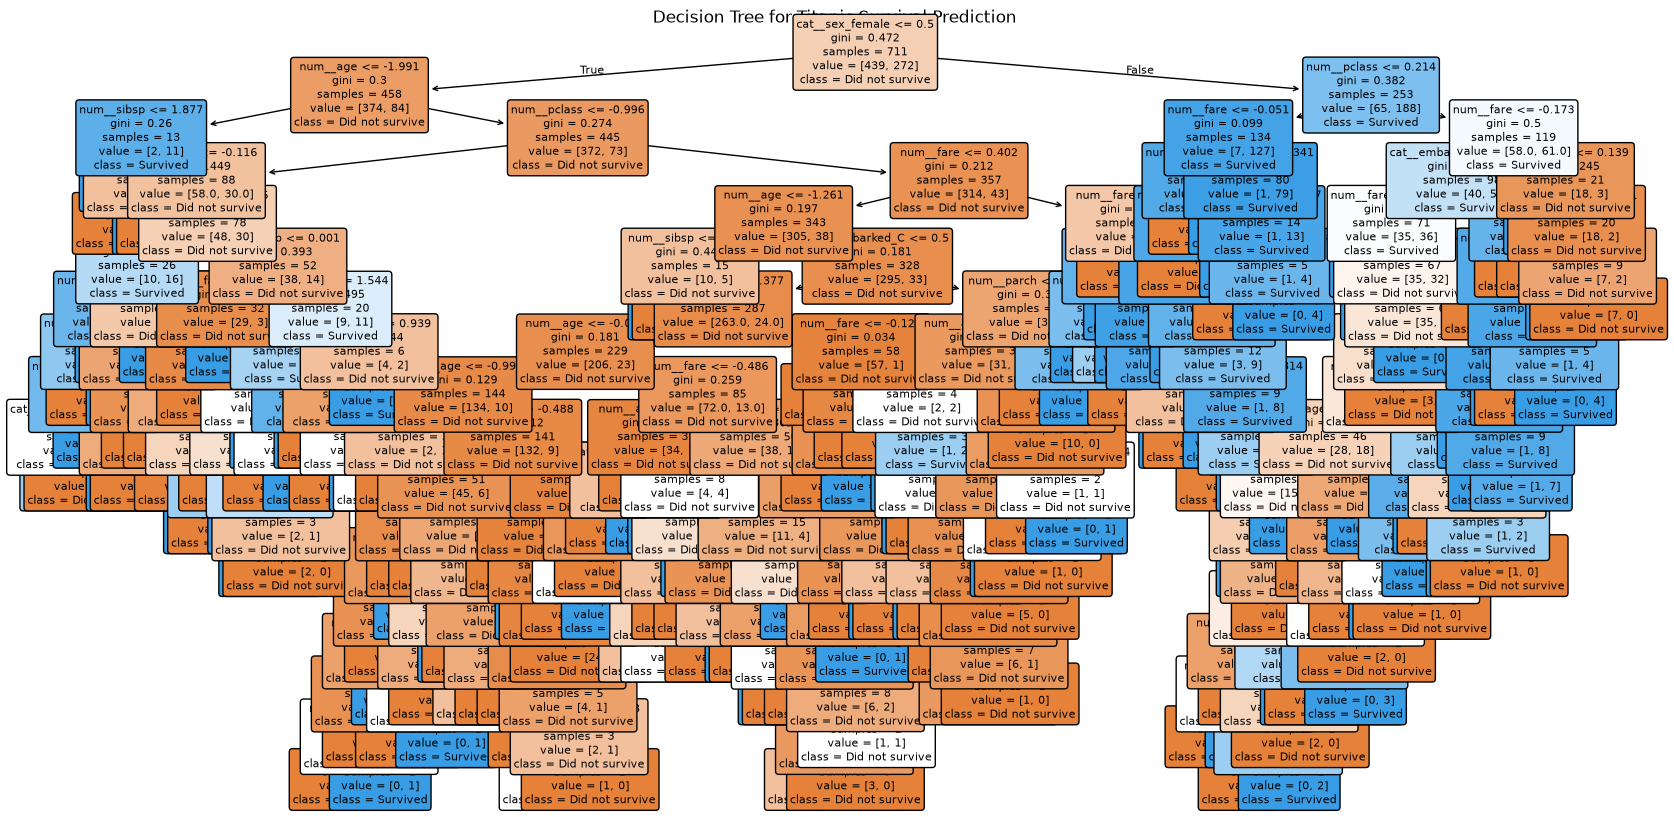

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

In [25]:
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTraining set class proportions:")
print(y_train.value_counts(normalize=True))

Training set class distribution:
survived
0    439
1    272
Name: count, dtype: int64

Training set class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64


In [26]:
balanced_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [27]:
balanced_rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [28]:
y_pred_balanced = balanced_rf_pipeline.predict(X_test)

print(y_pred_balanced[:20])

[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print("Balanced Random Forest")
print("----------------------")
print("Precision:", precision_balanced)
print("Recall   :", recall_balanced)
print("F1 Score :", f1_balanced)

Balanced Random Forest
----------------------
Precision: 0.7391304347826086
Recall   : 0.75
F1 Score : 0.7445255474452555


In [30]:
import imblearn

print(imblearn.__version__)

0.14.2


In [31]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [32]:
smote_rf_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [33]:
smote_rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](7,)","['pclass','sex','age',...,'parch','fare','embarked']"
n_features_in_,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [34]:
y_pred_smote = smote_rf_pipeline.predict(X_test)

print(y_pred_smote[:20])

[0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0]


In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("SMOTE Random Forest")
print("-------------------")
print("Precision:", precision_smote)
print("Recall   :", recall_smote)
print("F1 Score :", f1_smote)

SMOTE Random Forest
-------------------
Precision: 0.746031746031746
Recall   : 0.6911764705882353
F1 Score : 0.7175572519083969


In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"]
}

In [37]:
rf_grid = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

In [38]:
rf_grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_grid)
    ]
)

In [39]:
grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [40]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best CV F1 Score:
0.7408312771917277


In [42]:
best_rf = grid_search.best_estimator_

print(best_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'embarked'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=5, n_estimators=200,
                                        oob_score=True, random_state=42))])


In [43]:
best_rf_model = best_rf.named_steps["classifier"]

print("OOB Score:", best_rf_model.oob_score_)

OOB Score: 0.8213783403656821


In [44]:
y_pred_best = best_rf.predict(X_test)
y_probs_best = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_probs_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Accuracy : 0.8314606741573034
Precision: 0.8653846153846154
Recall   : 0.6617647058823529
F1 Score : 0.75
ROC-AUC  : 0.838903743315508

Confusion Matrix:
[[103   7]
 [ 23  45]]


In [45]:
from sklearn.model_selection import train_test_split

reg_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[reg_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_reg_train:", X_reg_train.shape)
print("X_reg_test :", X_reg_test.shape)
print("y_reg_train:", y_reg_train.shape)
print("y_reg_test :", y_reg_test.shape)

X_reg_train: (711, 6)
X_reg_test : (178, 6)
y_reg_train: (711,)
y_reg_test : (178,)


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), reg_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), reg_categorical_features)
    ]
)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("regressor", LinearRegression())
    ]
)

regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("First 10 actual fares:")
print(y_reg_test.head(10).values)

print("\nFirst 10 predicted fares:")
print(y_reg_pred[:10])

First 10 actual fares:
[  7.8542 120.      11.2417  13.      79.65     6.975   13.       8.6625
 110.8833 106.425 ]

First 10 predicted fares:
[ -2.88475489  95.99511931  27.79356729  29.18366602  89.39234588
  -2.76586876  29.77809669  -2.05255195 100.4411708   84.37654661]


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 21.138552296883084
RMSE: 41.746502315739114
R²  : 0.34677389181134055


In [49]:
feature_names_reg = (
    regression_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

p = len(feature_names_reg)
n = len(y_reg_test)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Number of predictors:", p)
print("Number of test observations:", n)
print("Adjusted R²:", adjusted_r2)

Number of predictors: 9
Number of test observations: 178
Adjusted R²: 0.3117796360155195


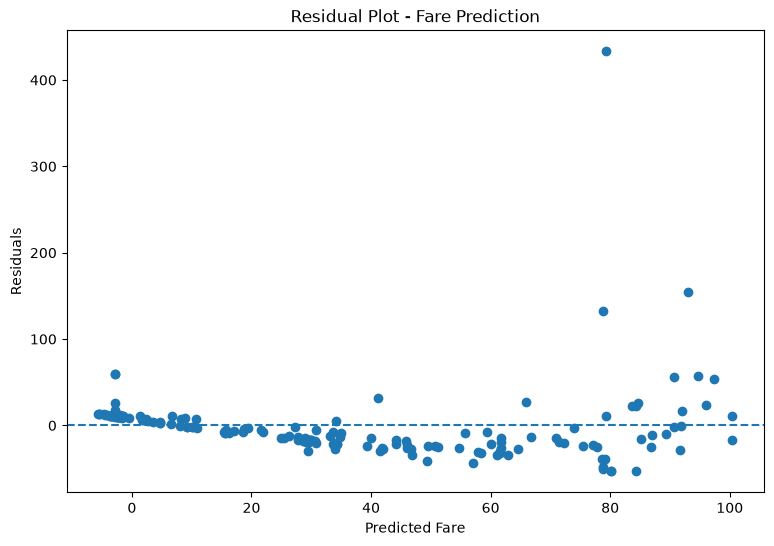

In [50]:
import matplotlib.pyplot as plt

residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_reg_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Fare Prediction")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.show()

In [51]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "Linear Regression"
    ],
    "Accuracy": [
        0.80899,
        0.76966,
        0.82022,
        0.83146,
        None
    ],
    "Precision": [
        0.78333,
        0.69014,
        0.78125,
        0.86538,
        None
    ],
    "Recall": [
        0.69118,
        0.72059,
        0.73529,
        0.66176,
        None
    ],
    "F1 Score": [
        0.73438,
        0.70504,
        0.75758,
        0.75000,
        None
    ],
    "ROC-AUC": [
        0.86096,
        0.75414,
        0.81791,
        0.83890,
        None
    ],
    "MAE": [
        None,
        None,
        None,
        None,
        21.13855
    ],
    "RMSE": [
        None,
        None,
        None,
        None,
        41.74650
    ],
    "R²": [
        None,
        None,
        None,
        None,
        0.34677
    ],
    "Adjusted R²": [
        None,
        None,
        None,
        None,
        0.31178
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic Regression,0.80899,0.78333,0.69118,0.73438,0.86096,NaN,NaN,NaN,NaN
1,Decision Tree,0.76966,0.69014,0.72059,0.70504,0.75414,NaN,NaN,NaN,NaN
2,Random Forest,0.82022,0.78125,0.73529,0.75758,0.81791,NaN,NaN,NaN,NaN
3,Tuned Random Forest,0.83146,0.86538,0.66176,0.75000,0.83890,NaN,NaN,NaN,NaN
4,Linear Regression,NaN,NaN,NaN,NaN,NaN,21.13855,41.7465,0.34677,0.31178


### Final Classifier Comparison

The tuned Random Forest achieved the highest test accuracy among the evaluated classifiers at 83.15% and the highest precision at 86.54%. Its recall was 66.18% and its F1-score was 75.00%, while its ROC-AUC was 0.839. Logistic Regression achieved a ROC-AUC of 0.861, which was higher than the tuned Random Forest, while the baseline Random Forest achieved an F1-score of 75.76%. Based on these test-set results and the cross-validation tuning process, the tuned Random Forest provides a strong overall classification pipeline, with particularly high precision.

In [52]:
import joblib

joblib.dump(
    best_rf,
    "titanic_final_pipeline.joblib"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [53]:
loaded_pipeline = joblib.load(
    "titanic_final_pipeline.joblib"
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [54]:
sample_raw = X_test.iloc[[0]]

print("Raw input:")
print(sample_raw)

prediction = loaded_pipeline.predict(sample_raw)

print("\nPrediction:")
print(prediction)

Raw input:
     pclass   sex   age  sibsp  parch  fare embarked
159       3  male  44.0      0      1  16.1        S

Prediction:
[0]
